# 1. Import des bibliothèques


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

import joblib



# 2. Préparation  et exploration des données

### Chargement et filtrage des données

In [2]:
# 📂 Chargement des données de Lille
df_lille_row = pd.read_csv('../data/lille_2022.csv')

# 🧹 Sélection des colonnes pertinentes
colonnes_utiles = [
    'Surface reelle bati',
    'Nombre pieces principales',
    'Type local',
    'Surface terrain',
    'Nombre de lots',
    'Valeur fonciere'
]
df_lille_row = df_lille_row[colonnes_utiles].copy()

# 🏷️ Ne garder que les Appartements et Maisons
df_lille_row = df_lille_row[df_lille_row['Type local'].isin(['Appartement', 'Maison'])]

# 🎯 Création de la variable cible : prix au m²
df_lille_row['prix_m2'] = df_lille_row['Valeur fonciere'] / df_lille_row['Surface reelle bati']
df_lille_row = df_lille_row.drop('Valeur fonciere', axis=1)

# 🧾 Vérification
print(df_lille_row['Type local'].value_counts())


print( "la dimension du dataframe:", df_lille_row.shape)




Type local
Appartement    4590
Maison         1174
Name: count, dtype: int64
la dimension du dataframe: (5764, 6)


### Traitement de valeurs manquantes
Dans le jeu de données, seules les valeurs de la variable Surface terrain présentent des valeurs manquantes. Cette variable concerne principalement les maisons, où elle est souvent renseignée, mais reste très fréquemment absente pour les appartements (plus de 370 cas). Deux stratégies étaient envisageables : soit supprimer la variable Surface terrain pour les appartements, considérant qu’elle n’a pas de sens dans un contexte collectif ; soit conserver la variable et remplacer les valeurs manquantes par 0, ce qui reflète le fait qu’un appartement ne dispose généralement pas de terrain privé.
J’ai opté pour la seconde option, en remplaçant les valeurs manquantes de Surface terrain par 0 dans le cas des appartements. Cette approche me permet de garder une structure de données homogène tout en restant cohérent avec la nature des biens.

In [3]:
# 🔁 Séparer les deux types de biens pour l'analyse
df_appartements = df_lille_row[df_lille_row['Type local'] == 'Appartement']
df_maisons = df_lille_row[df_lille_row['Type local'] == 'Maison']

# 🔎 Nombre de valeurs manquantes dans chaque dataset
print("🔍 Valeurs manquantes - Appartements :\n")
print(df_appartements.isna().sum())

print("\n🔍 Valeurs manquantes - Maisons :\n")
print(df_maisons.isna().sum())


🔍 Valeurs manquantes - Appartements :

Surface reelle bati             0
Nombre pieces principales       0
Type local                      0
Surface terrain              3427
Nombre de lots                  0
prix_m2                         0
dtype: int64

🔍 Valeurs manquantes - Maisons :

Surface reelle bati           0
Nombre pieces principales     0
Type local                    0
Surface terrain              46
Nombre de lots                0
prix_m2                       0
dtype: int64


In [4]:
# ➕ Créer un masque pour les appartements et maisons
mask_appartements = df_lille_row['Type local'] == 'Appartement'
mask_maisons = df_lille_row['Type local'] == 'Maison'

# ✅ Appartements : remplacer les NaN par 0
df_lille_row.loc[mask_appartements, 'Surface terrain'] = df_lille_row.loc[mask_appartements, 'Surface terrain'].fillna(0)

# ✅ Maisons : remplacer les NaN par la médiane des surfaces terrain des maisons
median_surface_terrain_maisons = df_lille_row.loc[mask_maisons, 'Surface terrain'].median()
df_lille_row.loc[mask_maisons, 'Surface terrain'] = df_lille_row.loc[mask_maisons, 'Surface terrain'].fillna(median_surface_terrain_maisons)

print("Valeurs manquantes après traitement :")
print(df_lille_row['Surface terrain'].isna().sum()) 



Valeurs manquantes après traitement :
0


### Traitement des valeurs aberrantes   
Concernant la détection et la suppression des valeurs aberrantes, j’ai choisi une méthode statistique rigoureuse fondée sur l’intervalle interquartile (IQR), utilisée notamment pour la lecture graphique des boîtes à moustaches. Cette méthode permet d’écarter les observations dont le prix au m² (prix_m2) est significativement éloigné du cœur de distribution (hors de l’intervalle [Q1 - 1.5×IQR, Q3 + 1.5×IQR]). Cela garantit un nettoyage objectif et reproductible des extrêmes sans introduire de seuil arbitraire.

In [5]:
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    borne_min = Q1 - 1.5 * IQR
    borne_max = Q3 + 1.5 * IQR

    df_cleaned= df[(df[column] >= borne_min) & (df[column] <= borne_max)]

    return df_cleaned, (borne_min, borne_max)

# Nettoyage des valeurs aberrantes sur le prix au m²
df_lille_cleaned, _ = remove_outliers_iqr(df_lille_row, 'prix_m2')





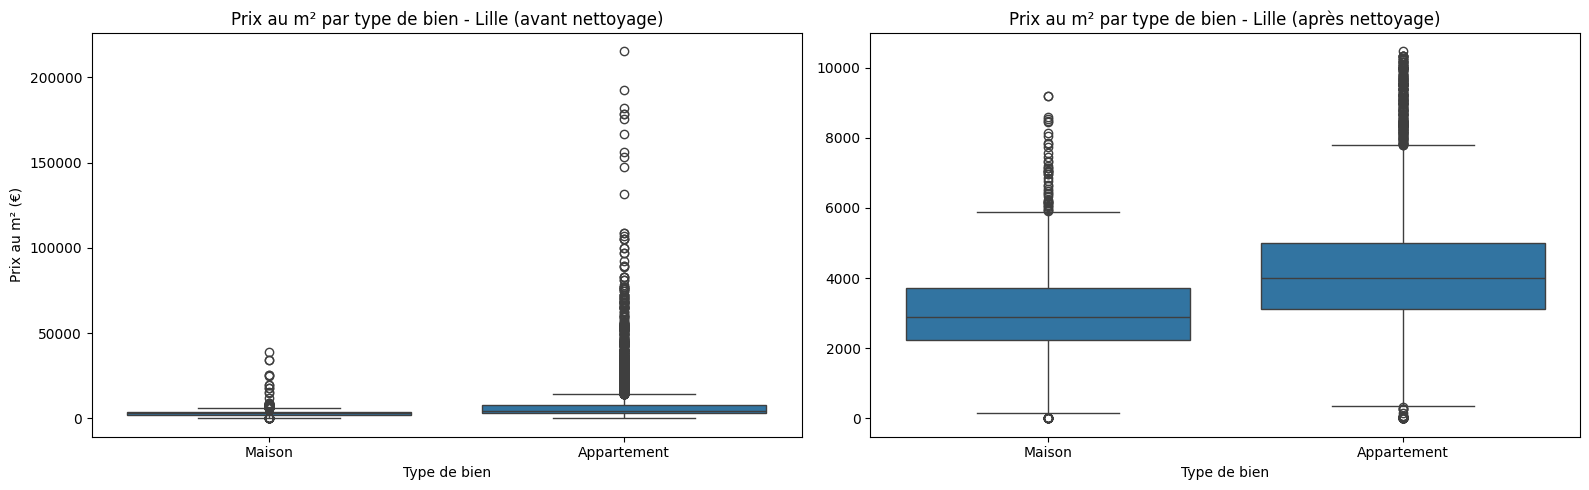

In [6]:

# Création des sous-graphes
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Graphique avant nettoyage
sns.boxplot(x=df_lille_row['Type local'], y=df_lille_row['prix_m2'], ax=axes[0], showfliers=True)
axes[0].set_title("Prix au m² par type de bien - Lille (avant nettoyage)")
axes[0].set_xlabel("Type de bien")
axes[0].set_ylabel("Prix au m² (€)")

# Graphique après nettoyage
sns.boxplot(x= df_lille_cleaned['Type local'], y=df_lille_cleaned['prix_m2'], ax=axes[1], showfliers=True)
axes[1].set_title("Prix au m² par type de bien - Lille (après nettoyage)")
axes[1].set_xlabel("Type de bien")
axes[1].set_ylabel("")

# Affichage
plt.tight_layout()
plt.show()


## Sauvgarde du dataframe de Lille après nettoyage

In [7]:
# Encodage du 'Type local' (catégorielle)
df_lille = pd.get_dummies(df_lille_cleaned, drop_first=True, dtype=int)
df_lille.to_csv("../data/df_lille.csv", index=False)
df_lille


,Surface reelle bati,Nombre pieces principales,Surface terrain,Nombre de lots,prix_m2,Type local_Maison
0,82.0,5.0,70.0,0,2681.707317,1
1,63.0,3.0,0.0,2,2936.507937,0
6,38.0,2.0,0.0,1,3167.105263,0
7,50.0,2.0,0.0,2,3600.000000,0
17,80.0,3.0,0.0,1,4232.500000,0
...,...,...,...,...,...,...
11347,70.0,3.0,0.0,2,4302.857143,0
11348,70.0,3.0,0.0,1,2485.714286,0
11351,78.0,4.0,0.0,1,2230.769231,0
11352,72.0,4.0,278.0,0,2777.777778,1


## Matrice de corrélation

In [8]:
# Afficher la corrélation entre les variables numériques et la cible 'prix_m2'
df_lille[['Surface reelle bati', 'Nombre pieces principales', 'Type local_Maison','Surface terrain', 'Nombre de lots', 'prix_m2']].corr()


,Surface reelle bati,Nombre pieces principales,Type local_Maison,Surface terrain,Nombre de lots,prix_m2
Surface reelle bati,1.000000,0.838063,0.431749,0.133034,-0.112215,-0.273800
Nombre pieces principales,0.838063,1.000000,0.551677,0.144877,-0.218866,-0.306491
Type local_Maison,0.431749,0.551677,1.000000,0.230390,-0.626420,-0.290244
Surface terrain,0.133034,0.144877,0.230390,1.000000,-0.196604,-0.030753
Nombre de lots,-0.112215,-0.218866,-0.626420,-0.196604,1.000000,-0.019000
prix_m2,-0.273800,-0.306491,-0.290244,-0.030753,-0.019000,1.000000


### Préparation des données pour la modélisation

Le prix au m² est calculé comme la valeur foncière divisée par la surface bâtie. Inclure la valeur foncière comme variable explicative créerait une erreur statistique appelée **"data leakage" (fuite de données)**.


En effet, cela génère un problème **d’endogénéité** rendant le modèle non fiable et peu généralisable.   

À l’inverse, la surface bâtie est une variable explicative pertinente. Bien qu’elle soit corrélée au prix au m², elle n’en est pas une conséquence directe. Deux biens de même surface peuvent avoir des prix très différents, ce qui signifie que la surface bâtie aide à expliquer la variabilité du prix au m² sans provoquer de fuite d’information.

Ce choix respecte un principe fondamental de la modélisation statistique (linéaire) : les variables explicatives doivent être causales ou au moins prédictives de la cible, et ne jamais être des transformations directes ou dérivées de cette dernière.


Ainsi, seules **la surface bâtie, le type du local, le nombre de lots et la surface terrain (pour les maisons)** sont utilisées comme variables explicatives pour construire le modèle.

In [9]:
# Variables explicatives et cible
features = ['Surface reelle bati', 'Nombre pieces principales', 'Type local_Maison', 'Surface terrain', 'Nombre de lots']
target = 'prix_m2'


X = df_lille[features]
y = df_lille[target]

# Split train/test 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


### Standardisation

La standardisation des variables numériques a été effectuée afin d’harmoniser leurs échelles, ce qui facilite la convergence et améliore la performance des modèles tels que la régression linéaire. Cette étape permet également de rendre les coefficients plus comparables entre eux. Bien que certains modèles, comme les arbres de décision, ne soient pas sensibles à l’échelle des données, la standardisation est considérée comme une bonne pratique pour assurer une comparaison juste et fiable entre différents algorithmes.

In [16]:


# Colonnes numériques à standardiser
num_features = ['Surface reelle bati', 'Nombre pieces principales', 'Surface terrain', 'Nombre de lots']

scaler = StandardScaler()

# Apprendre le scaler sur le train uniquement
X_train[num_features] = scaler.fit_transform(X_train[num_features])

# Appliquer la même transformation au test
X_test[num_features] = scaler.transform(X_test[num_features])

# Sauvgarde du scaler
joblib.dump(scaler, "../models/scaler_lille.pkl")
print("Scaler sauvegardé dans ../models/scaler_lille.pkl")

Scaler sauvegardé dans ../models/scaler_lille.pkl


# 3. Entrainemment des modèles

In [11]:
# Linear Regression
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Decision Tree
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

# Random Forest
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

# Optimisation de Random Forest
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}
grid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)
best_rf = grid_search.best_estimator_

# XGBoost
xgb_model = XGBRegressor(random_state=42, verbosity=0)
xgb_model.fit(X_train, y_train)


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


c:\Users\adjah\Desktop\Simplon\projets simplon\IA-Immobilier\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


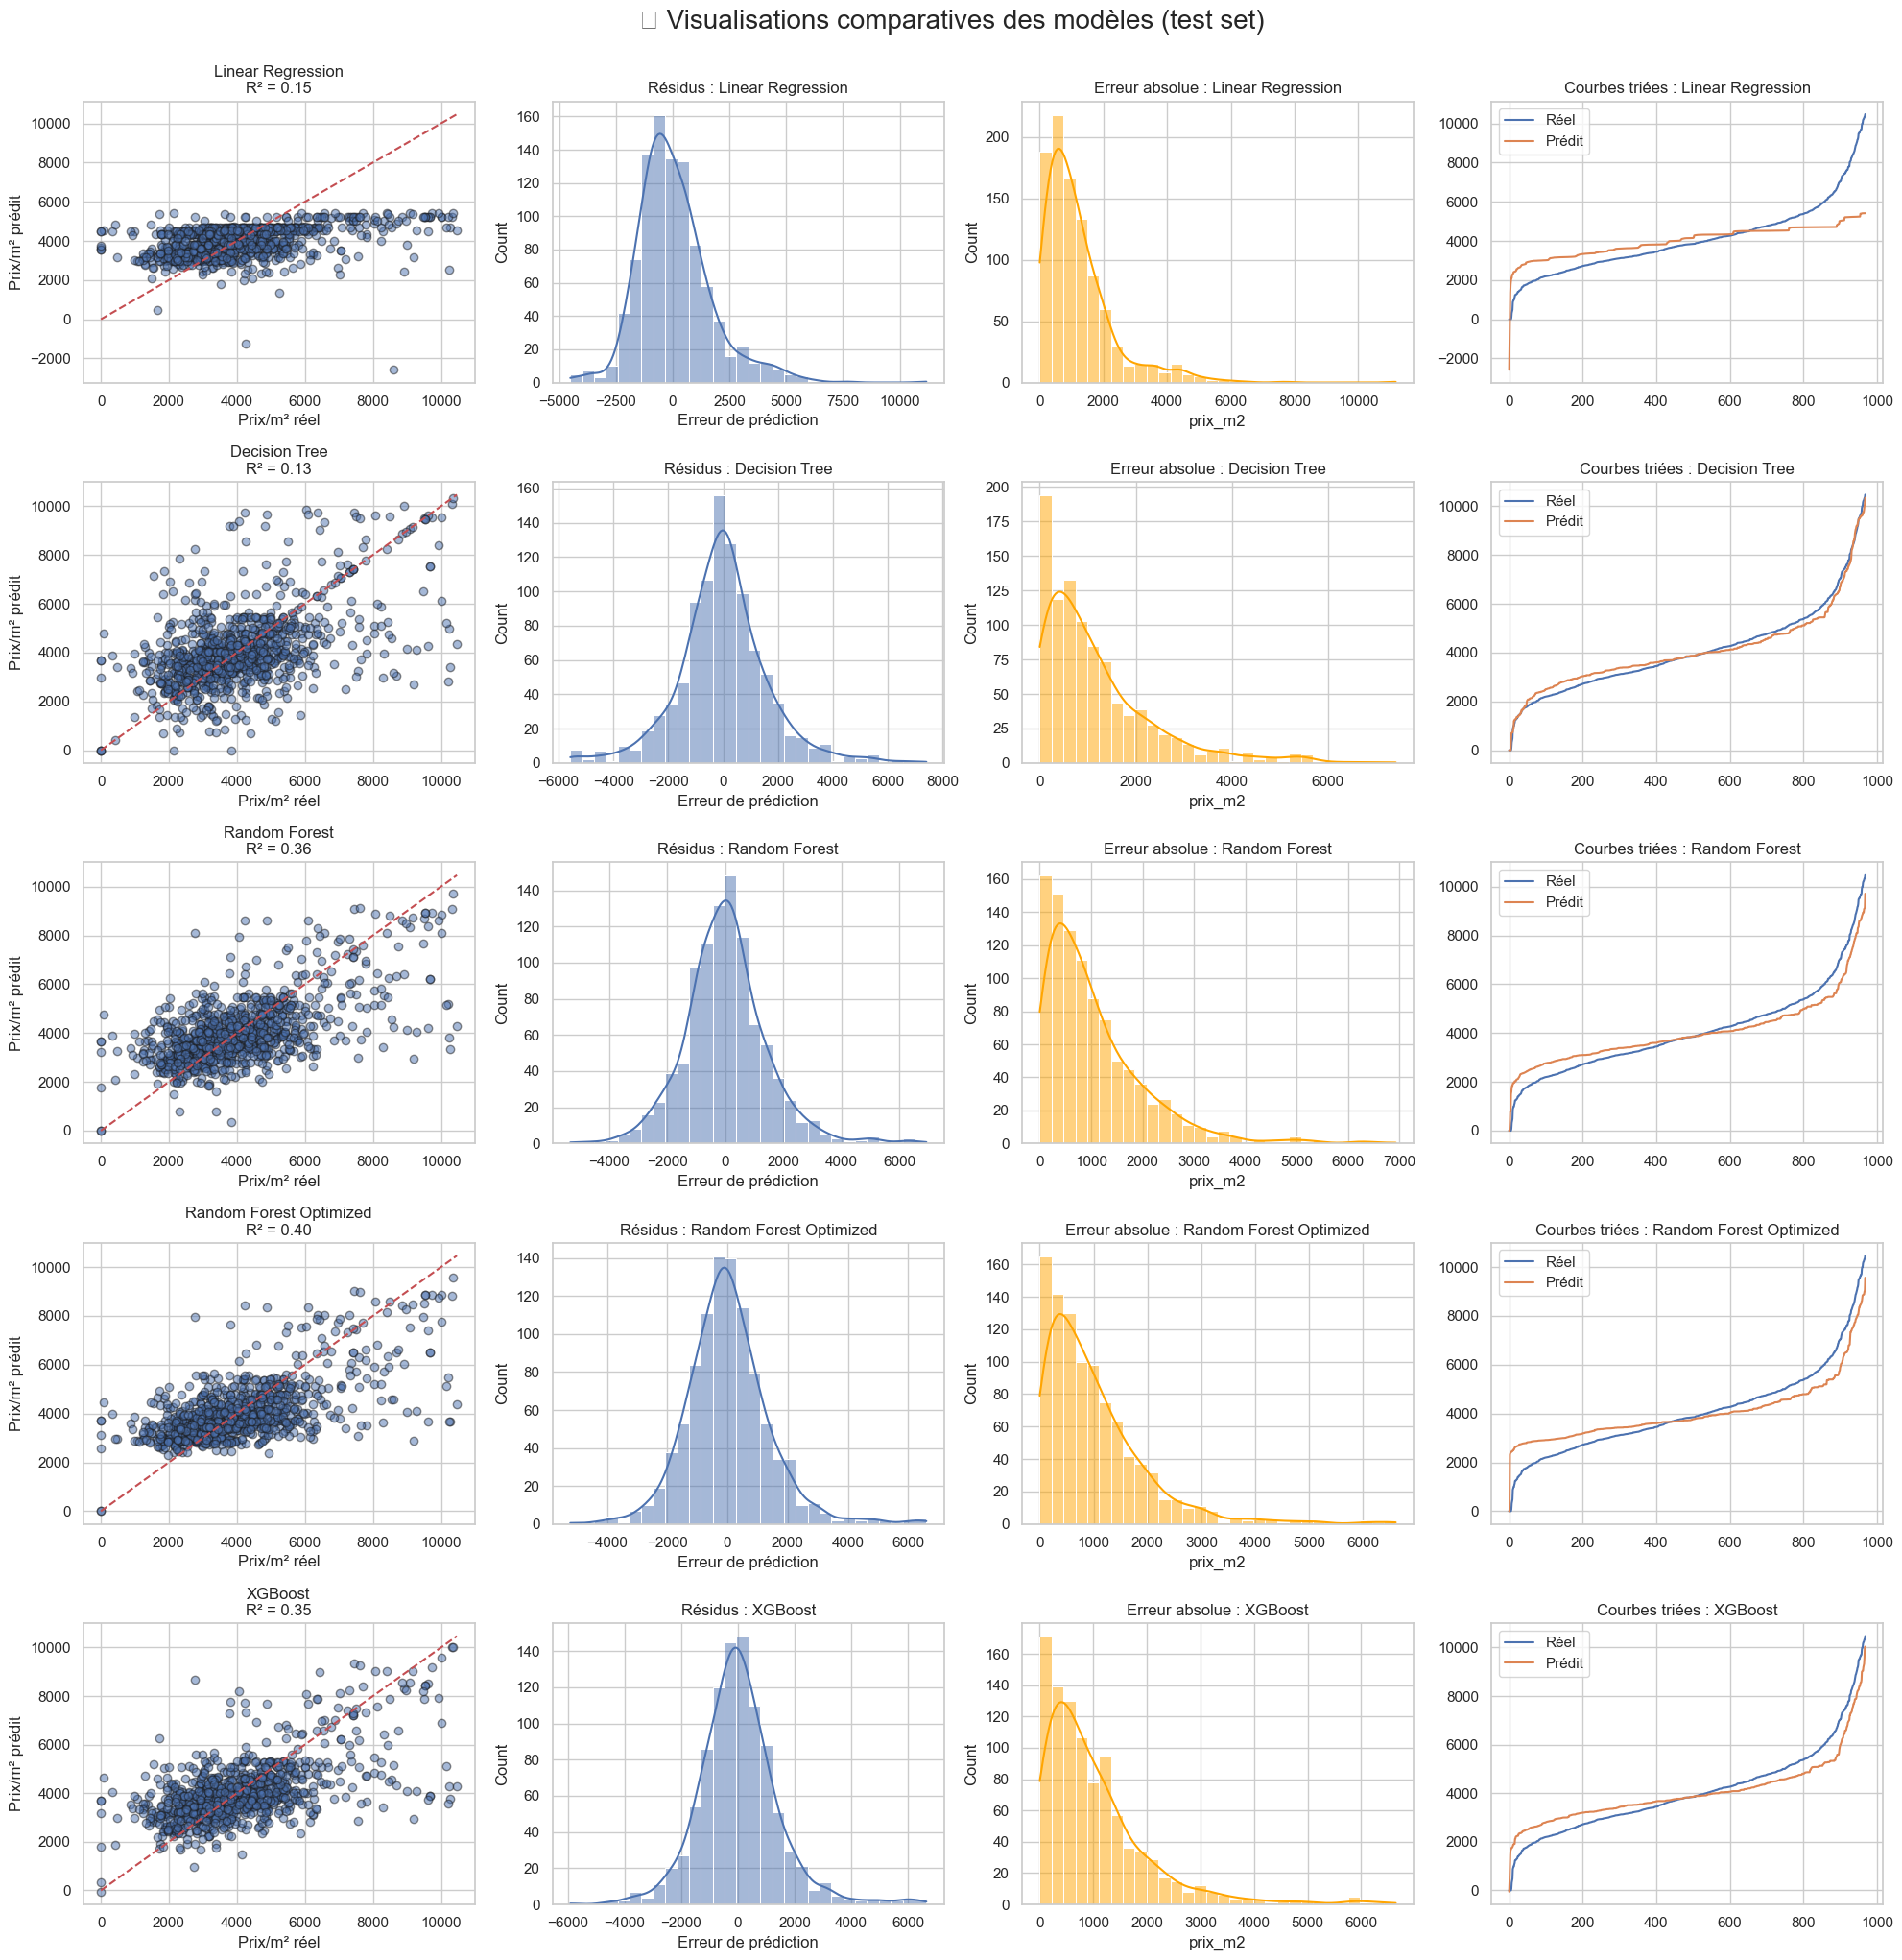

In [12]:
# Liste des modèles
models = {
    "Linear Regression": linear_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "Random Forest Optimized": best_rf,
    "XGBoost": xgb_model
}

# Style général
sns.set(style="whitegrid")
plt.figure(figsize=(20, 20))
plot_idx = 1

for name, model in models.items():
    y_pred = model.predict(X_test)
    residuals = y_test - y_pred
    abs_errors = abs(residuals)

    # --- 1. Réel vs Prédit ---
    plt.subplot(len(models), 4, plot_idx)
    plt.scatter(y_test, y_pred, alpha=0.5, edgecolor='k')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.xlabel("Prix/m² réel")
    plt.ylabel("Prix/m² prédit")
    plt.title(f"{name}\nR² = {r2_score(y_test, y_pred):.2f}")
    plot_idx += 1

    # --- 2. Résidus ---
    plt.subplot(len(models), 4, plot_idx)
    sns.histplot(residuals, bins=30, kde=True)
    plt.title(f"Résidus : {name}")
    plt.xlabel("Erreur de prédiction")
    plot_idx += 1

    # --- 3. Erreurs absolues ---
    plt.subplot(len(models), 4, plot_idx)
    sns.histplot(abs_errors, bins=30, kde=True, color="orange")
    plt.title(f"Erreur absolue : {name}")
    plot_idx += 1

    # --- 4. Courbe des valeurs triées ---
    plt.subplot(len(models), 4, plot_idx)
    plt.plot(sorted(y_test.values), label="Réel")
    plt.plot(sorted(y_pred), label="Prédit")
    plt.title(f"Courbes triées : {name}")
    plt.legend()
    plot_idx += 1

plt.tight_layout()
plt.suptitle("📊 Visualisations comparatives des modèles (test set)", fontsize=20, y=1.02)
plt.show()


# 4. Évaluation des performances

Nous avons évalué cinq modèles supervisés pour prédire le **prix au m²** des logements à Lille, en utilisant les métriques suivantes :

- **MSE** (Mean Squared Error) : plus c’est faible, mieux c’est
- **RMSE** (Root Mean Squared Error) : erreur moyenne en unité réelle (€/m²)
- **R²** (coefficient de détermination) : proportion de variance expliquée, proche de 1 = très bon modèle


In [13]:
# Initialisation
evaluation_results = {
    "Modèle": [],
    "MSE": [],
    "RMSE": [],
    "R²": []
}

# Dictionnaire des modèles
model_list = {
    "LinearRegression": linear_model,
    "DecisionTreeRegressor": dt_model,
    "RandomForestRegressor": rf_model,
    "RandomForest_Optimized": best_rf,
    "XGBoost": xgb_model
}

# Boucle d’évaluation
for name, model in model_list.items():
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    evaluation_results["Modèle"].append(name)
    evaluation_results["MSE"].append(mse)
    evaluation_results["RMSE"].append(rmse)
    evaluation_results["R²"].append(r2)

# Résultat sous forme de tableau
eval_df = pd.DataFrame(evaluation_results).sort_values(by="MSE").reset_index(drop=True)
eval_df


,Modèle,MSE,RMSE,R²
0,RandomForest_Optimized,1.889461e+06,1374.576679,0.404962
1,RandomForestRegressor,2.034264e+06,1426.276222,0.359360
2,XGBoost,2.054272e+06,1433.273143,0.353059
3,LinearRegression,2.710221e+06,1646.274986,0.146485
4,DecisionTreeRegressor,2.760676e+06,1661.528073,0.130596


# 5. Sauvegarde des modèles entraînés

In [14]:
# # Dictionnaire des chemins de sauvegarde pour chaque modèle
# model_save_paths = {
#     "Linear Regression": "../models/linear_model_bx.pkl",
#     "Decision Tree": "../models/dt_model_bx.pkl",
#     "Random Forest": "../models/rf_model_bx.pkl",
#     "Random Forest Optimized": "../models/best_rf_bx.pkl",
#     "XGBoost": "../models/xgb_model_bx.pkl"
# }

# # Sauvegarde de chaque modèle entraîné dans le dossier models pour une utilisation ultérieure
# for name, model in models.items():
#     path = model_save_paths[name]
#     joblib.dump(model, path)  # Sérialisation du modèle avec joblib

# model_paths = model_save_paths


In [17]:


# Dictionnaire des chemins de sauvegarde pour chaque modèle (facultatif, utile pour référence)
model_save_paths = {
    "Linear Regression": "../models/linear_model.pkl",
    "Decision Tree": "../models/dt_model.pkl",
    "Random Forest": "../models/rf_model.pkl",
    "Random Forest Optimized": "../models/best_rf.pkl",
    "XGBoost": "../models/xgb_model.pkl"
}


# Regrouper les modèles et les chemins dans un seul dictionnaire
all_data = {
    "models": models,
    "model_paths": model_save_paths
}

# Chemin du fichier unique contenant tous les modèles
all_models_path = "../models/model_lille.pkl"

# Sauvegarde dans un seul fichier
joblib.dump(all_data, all_models_path)

print(f"Tous les modèles ont été sauvegardés dans : {all_models_path}")


Tous les modèles ont été sauvegardés dans : ../models/model_lille.pkl


# 🎯 Conclusion   

🏆 Meilleur modèle : **RandomForest_Optimized**
Grâce à la recherche d’hyperparamètres via GridSearchCV, ce modèle offre les meilleurs scores sur toutes les métriques :

Plus faible MSE et RMSE, donc les prédictions sont proches des valeurs réelles.

Meilleur R², ce qui indique qu’il explique le plus de variance dans le prix au m².

Ce modèle est donc le plus robuste et généralisable pour estimer le prix au m² à partir des caractéristiques des biens.


📈 RandomForestRegressor (modèle de base) arrive juste derrière.
Même sans optimisation, la forêt aléatoire est naturellement bien adaptée aux données tabulaires hétérogènes. Sa performance confirme sa capacité à gérer les interactions non linéaires et les effets croisés entre variables.


📈 XGBoost, souvent très performant en compétition, est ici légèrement en retrait.
Cela peut s’expliquer par :

L’absence de tuning d’hyperparamètres (pas de GridSearch appliqué)

Une sensibilité aux petits jeux de données ou aux données peu bruitées


📈 DecisionTreeRegressor (un seul arbre) montre des performances plus faibles.
Son faible R² et sa forte erreur quadratique traduisent un overfitting : il apprend parfaitement l'entraînement, mais généralise mal.

📈 LinearRegression est le modèle le moins performant :

Il suppose des relations linéaires entre les variables, ce qui est trop restrictif ici.

Son R² faible indique une incapacité à capturer la complexité des relations entre caractéristiques et prix